# [LAB 07] 10. 상관분석의 이해
## #01. 준비작업
### 1. 라이브러리 참조

In [1]:
from hossam import load_data
from helpers import *
from pandas import DataFrame

import numpy as np
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import pearsonr, spearmanr

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.19


### 2. 데이터 가져오기

In [2]:
origin = load_data('language_math_scores')
origin.head()

📚 어느 학급의 언어영역과 수리영역 점수를 기록한 가상의 데이터 셋


,언어영역,수리영역
0,66,66
1,58,70
2,73,74
3,52,58
4,72,79


## #02. 상관분석의 가정 확인
### 1. 정규성

In [3]:
report = my_stats.test_assumptions(origin, columns=['언어영역', '수리영역'])
norm_x = bool(report.loc['언어영역', 'result'])
norm_y = bool(report.loc['수리영역', 'result'])
print(f'정규성 → 언어영역:{norm_x}, 수리영역:{norm_y}')

정규성 → 언어영역:True, 수리영역:True


### 2. 선형성
- X가 증가할 때 Y도 증가하거나 감소하는 형태가 선형으로 분포해야 한다.
- 곡선형태로 분포할 경우 상관계수가 매우 낮거나 0의 상관을 보인다.
- 산점도 그래프를 통해 분석가가 직접 눈으로 보고 주관적으로 판단하는 것이 일반적이다.

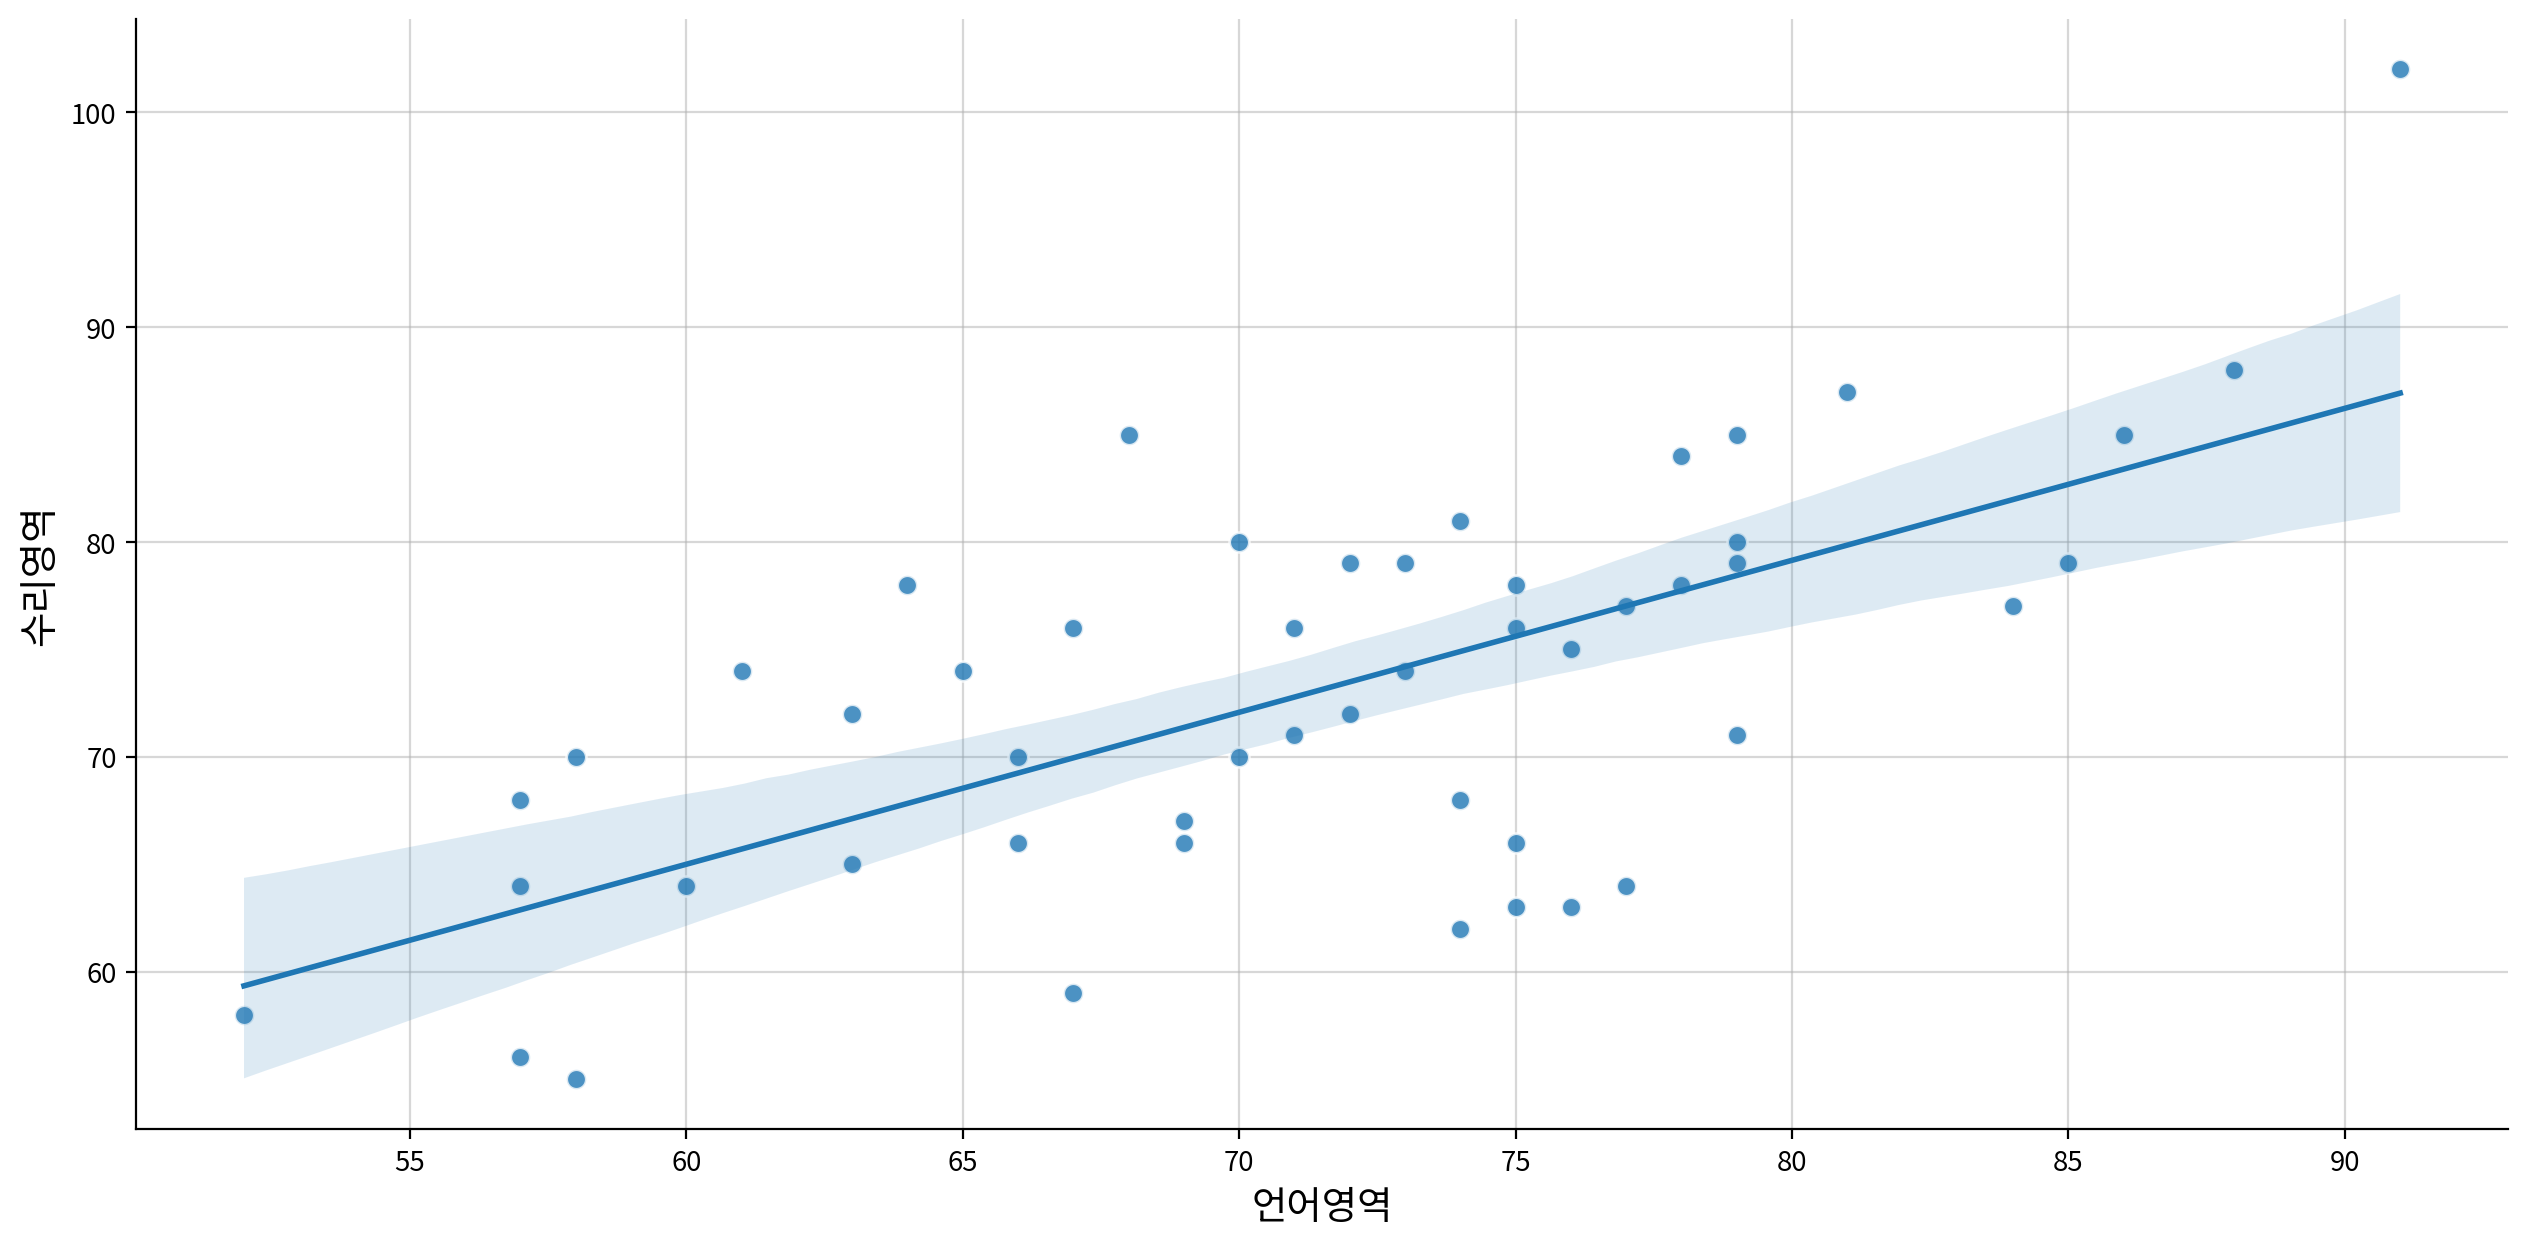

In [4]:
my_plot.lmplot(origin, x='언어영역', y='수리영역')

- 인사이트
    - 언어영역 점수가 높을수록 수리영역 점수도 함께 높아지는 경향이 있음
    - 두 변수는 대체로 직선적인 관계를 보임
    - 다만 점들이 넓게 퍼져있어 관계가 아주 강하다고 보긴 어려움
    - 일부 벗어난 점도 보여서 해석할 때 같이 봐야함

### 3. 선형성의 통계적 검정(Ramsey RESET Test)
- 회귀모델이 선형인지 검정하는 방법
    - 변수간의 선형성을 직접적으로 검정하는 방법은 아니기 때문에 보조적인 방법으로 활용해야 함
    - p>= 0.05 : 선형성 적합(피어슨 상관계수 사용가능)
    - p<0.05 : 선형성 위반 (스피어만 상관계수 사용권장)

In [5]:
x=origin['언어영역']
y=origin['수리영역']

X=sm.add_constant(x)  # 상수항 추가(선형회귀에서 자세히 다룸)
model = sm.OLS(y, X).fit()
reset = linear_reset(model, power=2, use_f=True)

print(f'Ramsey RESET Test : {reset.pvalue:.4f}')

Ramsey RESET Test : 0.1884


### 4. 이상치 점검

In [6]:
results = {}

for col in ['언어영역', '수리영역']:
    # 특정변수만 결측치를 제거하고 추출
    temp = origin[col].dropna()

    # 사분위수 기반 이상치 개수 계산
    q1 = temp.quantile(0.25)
    q3 = temp.quantile(0.75)
    iqr = q3 -q1
    out_iqr = int(np.sum((temp < q1 - 1.5 * iqr) | (temp > q3 + 1.5 * iqr)))

    results[col] = {
        # 왜도 (분포의 비대칭성)
        'skew' : temp.skew(),
        # 사분위수(IQR) 기반 이상치 개수
        'outliers(IQR)' : out_iqr
    }

results_df = DataFrame(results).T
results_df

,skew,outliers(IQR)
언어영역,-0.103,0.000
수리영역,0.367,1.000


### 5. 이상치에 따른 상관계수 변화 확인

In [7]:
# 두 변수를 함께 결측 제거한 원본 데이터
df_full = origin[["언어영역", '수리영역']].dropna()

# IQR(사분위수) 울타리를 벗어나지 않은 행만 남겨 이상치 제거 데이터프레임을 별도로 생성
df_trim = df_full.copy()

for col in ["언어영역", '수리영역']:
    # 울타리는 항상 원본(df_full) 기준으로 계산
    q1 = df_full[col].quantile(0.25)
    q3 = df_full[col].quantile(0.75)
    iqr = q3 - q1
    df_trim = df_trim[(df_trim[col] >= q1 - 1.5 * iqr) &
                      (df_trim[col] <= q3 + 1.5 * iqr)]
    
# 원본과 이상치 제거 데이터에 대한 피어슨 상관계수 계산
r_full = pearsonr(df_full['언어영역'], df_full['수리영역'])[0]
r_trim = pearsonr(df_trim['언어영역'], df_trim['수리영역'])[0]

print(f'피어슨 r (전체)       : {r_full:.3f}  (n={len(df_full)})')
print(f'피어슨 r (이상치 제외) : {r_trim:.3f}  (n={len(df_trim)})')
print(f'변화량                : {abs(r_full-r_trim):.3f}')

피어슨 r (전체)       : 0.671  (n=50)
피어슨 r (이상치 제외) : 0.622  (n=49)
변화량                : 0.049


### 6. 이상치 영향 판정

In [8]:
# 왜도가 크다(|skew|>1)
skew_flag = bool((results_df['skew'].abs()>1).any())

# 이상치가 상관계수를 크게 바군다
influential_flag = bool(abs(r_full - r_trim) >=0.1)

print(f'이상치 영향 : {influential_flag or skew_flag}')

이상치 영향 : False


- 상관분석의 가정(선형성, 이상치 영향)을 확인한 결과 선형성을 만족하고 이상치에 영향을 받지 않으므로 Pearson 상관계수를 채택한다.

## #03. 모듈화 기능 확인
### 1. 가정 확인 → 상관분석 자동화

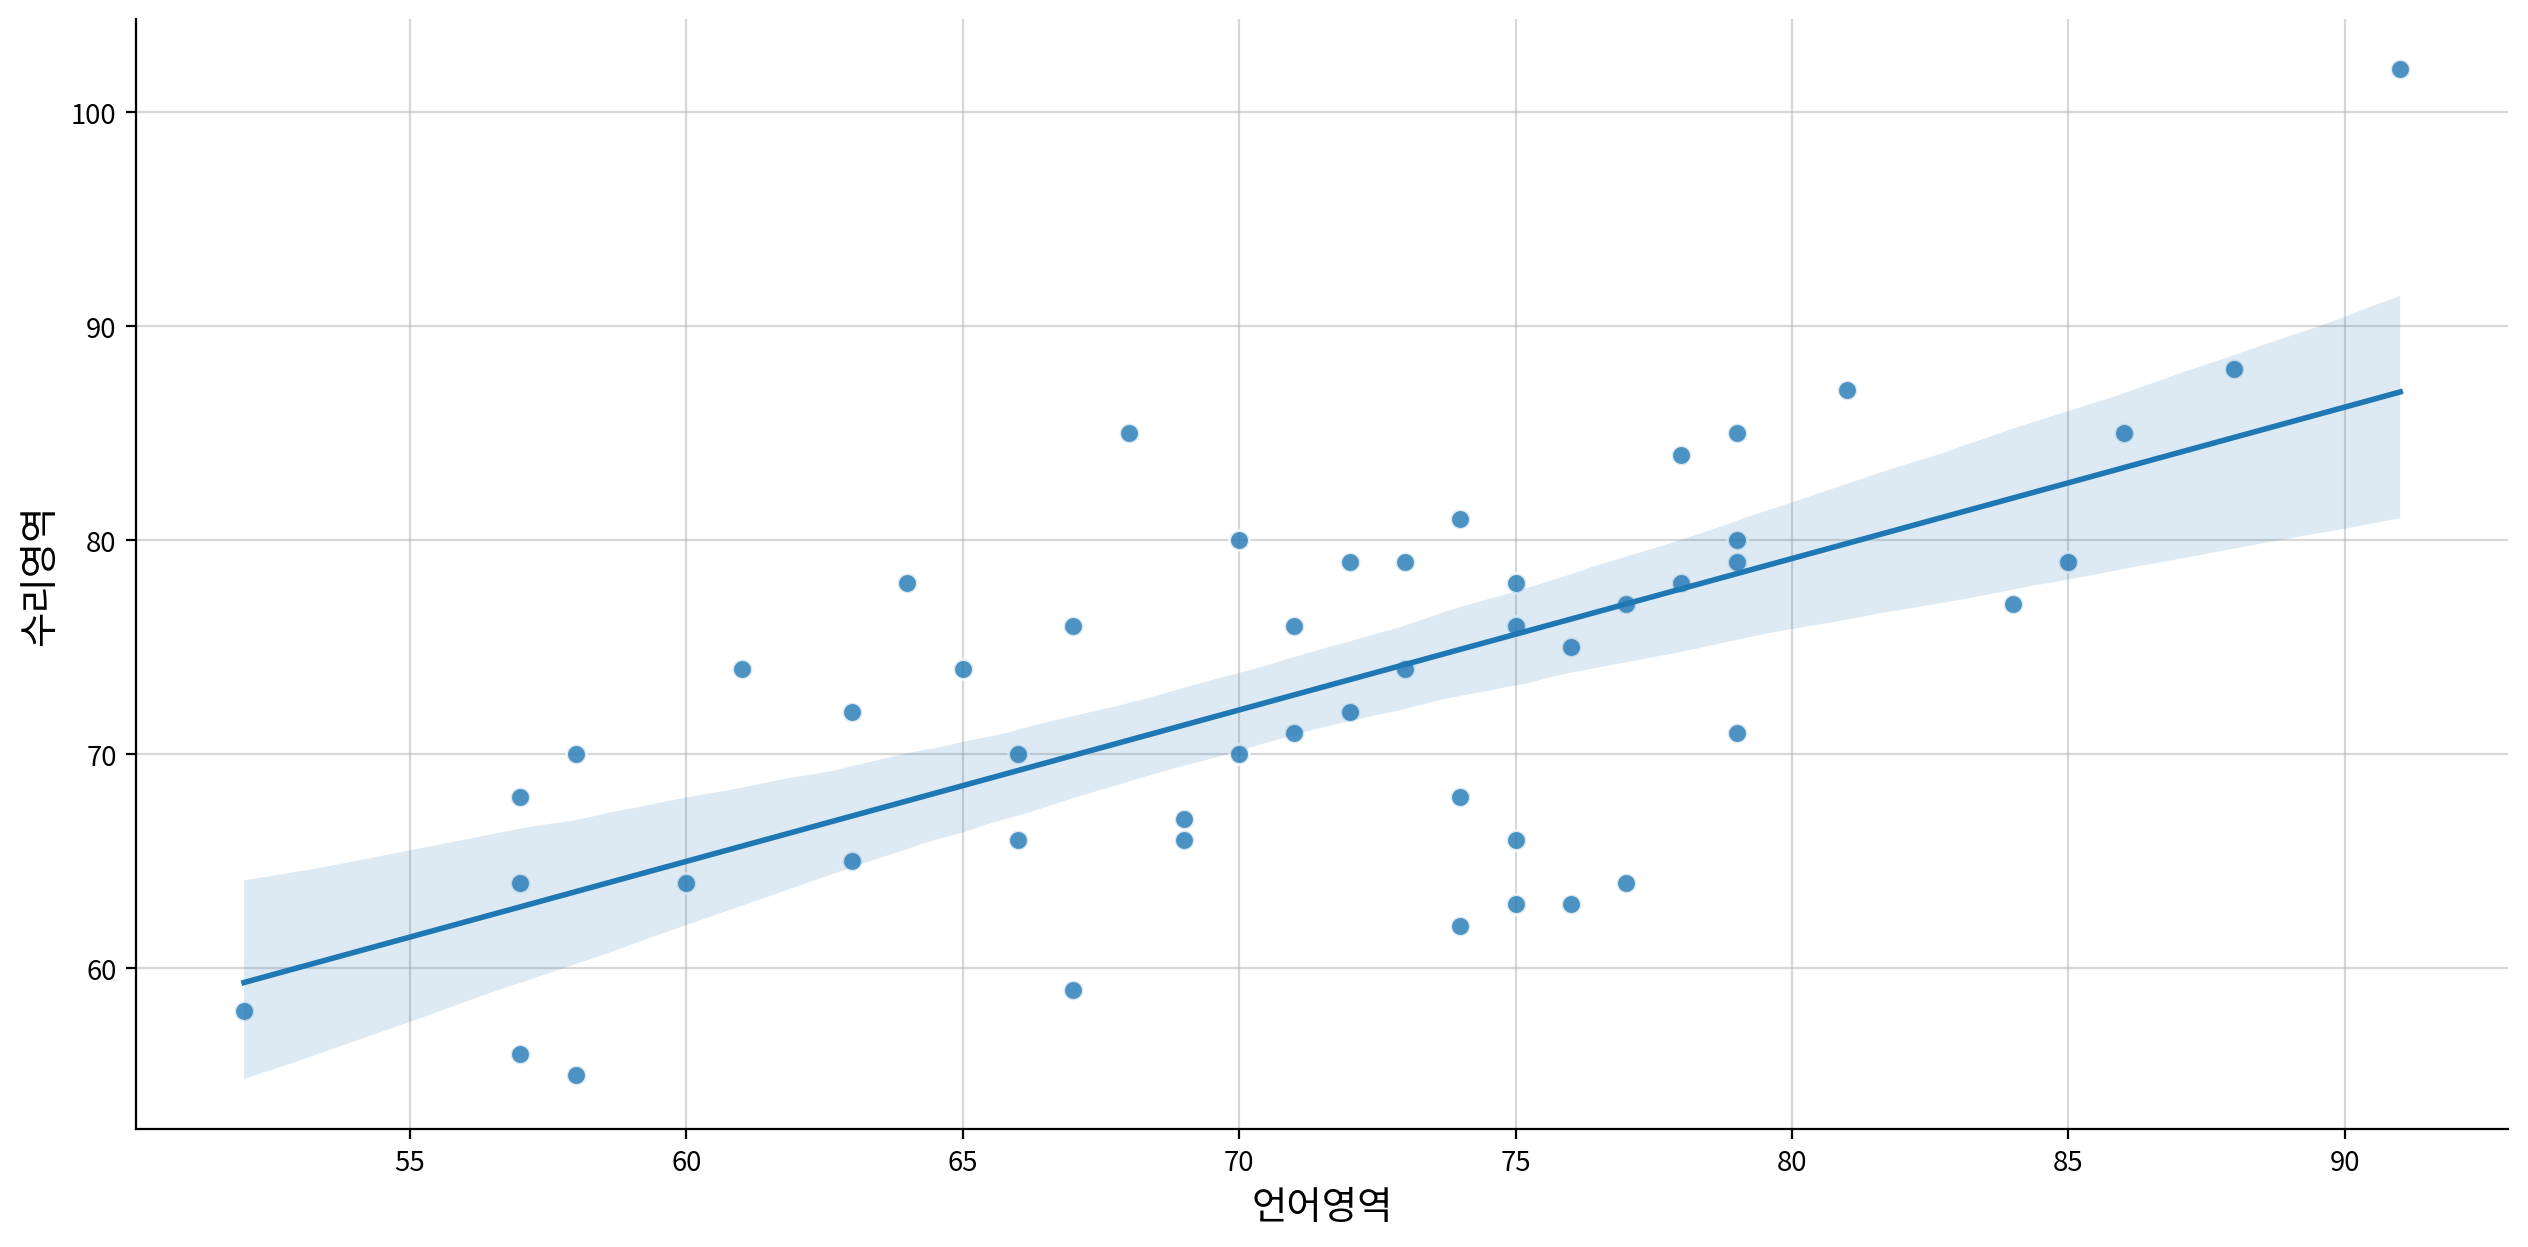

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
언어영역,수리영역,Pearson,0.671,0.000,Moderate,True,True,True,True,False,False


In [9]:
my_stats.correlation(origin, '언어영역', '수리영역')

- 중간정도의 양의 상관관계 - 피어슨 계수 0.674(strength: Moderate). 언어영역 점수가 높을수록 수리영역 점수도 함께 높아지는 경향이 있음
- 통계적으로 유의함 - p-value는 0.000(<0.05), significant=True. 이 상관관계는 우연으로 보기 어려움
- 피어슨 계수를 쓰는 것이 타당 - 정규성(언어 수리 모두 True), 선형성(True)을 충족하고, 영향점(influential_outlier=False), 큰 왜도(high_skew=False)도 없어 스피어만이 아닌 피어슨이 적절한 상황
- 모든 가정을 만족 -> 결과 신뢰 가능 - 정규성/선형성/이상치 영향 점검을 모두 통과했으므로 해석에 무리가 없음
- 다만 '강한' 관계는 아님 - Moderate 수준이라 점들이 어느 정도 퍼져있음, 한 영역 점수만응로 다른 영역 점수를 단정적으로 예측하기는 어려움